In [1]:
import math
import sys

import torch
import torch.nn as nn
import yaml

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns

from eeg.gesture2hand import TemporalDataset, TemporalModel
from eeg.gesture2hand.datasets.utils import Colors

In [ ]:
with open("../config/temporal.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)

    stride = config["stride"]
    val_ratio = config["val_ratio"]
    num_features = config["num_features"]
    d_model = 128
    num_heads = 4
    num_layers = 4
    dropout = config["dropout"]
    vocab_size = config["vocab_size"]

    device = config["device"]
    batch_size = config["batch_size"]
    sequence_length = config["seq_length"]
    save_ckpt_path = config["save_ckpt_path"]

gesture_labels = ["Fist", "Left", "Fingers", "Open"]

print(f"DEBUG: vocab_size from config = {vocab_size}")
print(f"DEBUG: gesture_labels has {len(gesture_labels)} classes")
if vocab_size != len(gesture_labels):
    print(f"WARNING: vocab_size ({vocab_size}) != num gesture classes ({len(gesture_labels)})")


In [27]:
print(f"{Colors.HEADER}Loading validation dataset...{Colors.ENDC}")
val_dataset = TemporalDataset(
    mode="val",
    seq_len=sequence_length,
    stride=stride,
    device=device,
    verbose=True,
    region_tokenizer_path="../models/appendages",
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    drop_last=False,
    shuffle=True
)

print(f"{Colors.OKGREEN}Dataset loaded. Validation batches: {len(val_loader)}{Colors.ENDC}\n")


Loading validation dataset...
Initializing dataset...
Getting VQVAE model...
Getting EEG data...
Computing bandpower features at 128.0 Hz...
Number of frequencies: (65,)
Bandpower features shape: (243912, 84) or (T, 84)
Filtered & processed EEG data.
Getting labels...
Getting appendage data...
Retrieved appendage data.
Successful retrieved all data.
Pre-computing VQ-VAE tokens...


100%|██████████| 112/112 [01:27<00:00,  1.28it/s]


EEG shape (30Hz):    (228491, 14)
Bandpower shape:     (228491, 84)
Appendages shape:    (228491, 12)
VQ-VAE tokens shape: (228491,)
Labels shape:        (228491,)


EEG chunks (30Hz):    (228491, 14)
Bandpower chunks:     (228491, 84)
Appendages chunks:    (228491, 12)
VQ-VAE tokens chunks: (228491,)
Labels chunks:        (228491,)

Number of blocks: (1903,) 

Splitting data into train and val sets...

Total number of chunks: 1516

Training/validation split index: 1516

Fist chunks (25.7% open)
Left chunks (13.2% open)
Fingers chunks (11.1% open)
Open chunks (50.0% open)

Dataset loaded. Validation batches: 48



In [28]:
print(f"{Colors.HEADER}Loading model...{Colors.ENDC}")
model = TemporalModel(
    num_features=num_features,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
    vocab_size=vocab_size,
).to(device)

param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of model parameters: {param_count:,}")

print(vocab_size)

Loading model...
Number of model parameters: 545,445
4


In [35]:
def load_checkpoint(epoch: int | None = None) -> bool:
    """Load model checkpoint. Returns True if successful."""
    if epoch is not None:
        ckpt_path = f"{save_ckpt_path}_epoch_{epoch}.pth"
    else:
        ckpt_path = f"{save_ckpt_path}.pth"
    
    try:
        state_dict = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state_dict["model"])
        print(f"{Colors.OKGREEN}Loaded checkpoint: {ckpt_path}{Colors.ENDC}\n")
        return True
    except FileNotFoundError:
        print(f"{Colors.FAIL}Checkpoint not found: {ckpt_path}{Colors.ENDC}")
        print(f"{Colors.WARNING}Using random initialization for inference{Colors.ENDC}\n")
        return False
    except RuntimeError as e:
        print(f"{Colors.FAIL}Error loading checkpoint (shape mismatch?): {e}{Colors.ENDC}")
        print(f"{Colors.WARNING}Using random initialization for inference{Colors.ENDC}\n")
        return False

# Load most recent checkpoint (epoch_150 has vocab_size=4)
load_checkpoint(epoch=150)


Loaded checkpoint: /var/log/thavamount/eeg_ckpts/temporal/sampler/sampler_big_epoch_150.pth



True

In [36]:
model.eval()

all_predictions = []
all_labels = []
all_probs = []

print(f"{Colors.OKBLUE}Running inference on validation set...{Colors.ENDC}")
with torch.no_grad():
    for batch_idx, (eeg, bp, apps, tokens, labels, durations, masks) in enumerate(tqdm(val_loader)):
        # Debug: print first batch details
        if batch_idx == 0:
            print(f"\nDEBUG - First batch shapes:")
            print(f"  eeg shape: {eeg.shape if hasattr(eeg, 'shape') else type(eeg)}")
            print(f"  bp shape: {bp.shape}")
            print(f"  labels shape: {labels.shape}, values: {labels[:5]}")
            print(f"  labels dtype: {labels.dtype}")
        
        # move to device
        bp = bp.to(device)  # (B, T, 84)
        labels = labels.to(device)  # (B,)
        
        # forward pass
        logits = model(bp)  # (B, vocab_size)
        
        # Debug: check logits
        if batch_idx == 0:
            print(f"  logits shape: {logits.shape}, sample logits: {logits[0]}")
            print(f"  logits contains NaN: {torch.isnan(logits).any()}")
            print(f"  logits contains Inf: {torch.isinf(logits).any()}")
        
        # get predictions and probabilities
        probs = torch.softmax(logits, dim=1)  # (B, vocab_size)
        preds = torch.argmax(logits, dim=1)  # (B,)
        
        # Debug: check predictions
        if batch_idx == 0:
            print(f"  predictions: {preds[:5]}, unique values: {torch.unique(preds)}")
        
        # store results
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(f"\nDEBUG - Final arrays:")
print(f"  all_predictions shape: {all_predictions.shape}, unique: {np.unique(all_predictions)}")
print(f"  all_labels shape: {all_labels.shape}, unique: {np.unique(all_labels)}")
print(f"  all_labels distribution: {np.bincount(all_labels.astype(int), minlength=4)}")

print(f"\n{Colors.OKGREEN}Inference complete!{Colors.ENDC}")
print(f"Total samples: {len(all_predictions)}\n")

Running inference on validation set...


  4%|▍         | 2/48 [00:00<00:04, 10.98it/s]


DEBUG - First batch shapes:
  eeg shape: torch.Size([32, 120, 14])
  bp shape: torch.Size([32, 120, 84])
  labels shape: torch.Size([32]), values: tensor([0, 3, 1, 1, 1])
  labels dtype: torch.int64
  logits shape: torch.Size([32, 4]), sample logits: tensor([ 1.8308,  1.6051, -5.2285,  0.4599])
  logits contains NaN: False
  logits contains Inf: False
  predictions: tensor([0, 0, 1, 0, 1]), unique values: tensor([0, 1, 2, 3])


100%|██████████| 48/48 [00:05<00:00,  9.08it/s]


DEBUG - Final arrays:
  all_predictions shape: (1516,), unique: [0 1 2 3]
  all_labels shape: (1516,), unique: [0 1 2 3]
  all_labels distribution: [407 202 151 756]

Inference complete!
Total samples: 1516



In [37]:
overall_accuracy = accuracy_score(all_labels, all_predictions)
print(f"{Colors.HEADER}=== VALIDATION METRICS ==={Colors.ENDC}")
print(f"Overall Accuracy: {overall_accuracy:.4f}\n")

# per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_predictions, average=None, labels=range(vocab_size)
)

print(f"{Colors.OKBLUE}Per-Class Metrics:{Colors.ENDC}")
print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 58)

# Only print metrics for classes that exist in vocab_size
for i in range(vocab_size):
    label_name = gesture_labels[i] if i < len(gesture_labels) else f"Class_{i}"
    print(
        f"{label_name:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} "
        f"{f1[i]:<12.4f} {int(support[i]):<10}"
    )

# macro averages
print(f"\n{Colors.OKCYAN}Macro Averages:{Colors.ENDC}")
print(f"Precision: {precision.mean():.4f}")
print(f"Recall:    {recall.mean():.4f}")
print(f"F1-Score:  {f1.mean():.4f}\n")

# weighted averages
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average="weighted", labels=range(vocab_size)
)
print(f"{Colors.OKCYAN}Weighted Averages:{Colors.ENDC}")
print(f"Precision: {prec_weighted:.4f}")
print(f"Recall:    {rec_weighted:.4f}")
print(f"F1-Score:  {f1_weighted:.4f}\n")

# per-class accuracy
print(f"{Colors.OKBLUE}Per-Class Accuracy (Recall):{Colors.ENDC}")
for i in range(vocab_size):
    label_name = gesture_labels[i] if i < len(gesture_labels) else f"Class_{i}"
    class_mask = all_labels == i
    if class_mask.sum() > 0:
        class_accuracy = accuracy_score(all_labels[class_mask], all_predictions[class_mask])
        print(f"{label_name:<12}: {class_accuracy:.4f}")

# --- error analysis ---

errors = all_predictions != all_labels
correct = all_predictions == all_labels

print(f"\n{Colors.HEADER}Error Analysis{Colors.ENDC}")
print(f"Total errors: {errors.sum()} / {len(all_predictions)} ({100 * errors.sum() / len(all_predictions):.2f}%)")
print(f"Correct: {correct.sum()} / {len(all_predictions)} ({100 * correct.sum() / len(all_predictions):.2f}%)\n")

# most common confusions
if errors.sum() > 0:
    error_indices = np.where(errors)[0]
    error_labels = all_labels[error_indices]
    error_predictions = all_predictions[error_indices]
    
    print(f"{Colors.OKBLUE}Most Common Confusions (Top 10):{Colors.ENDC}")
    confusions = {}
    for gt, pred in zip(error_labels, error_predictions):
        gt_name = gesture_labels[gt] if gt < len(gesture_labels) else f"Class_{gt}"
        pred_name = gesture_labels[pred] if pred < len(gesture_labels) else f"Class_{pred}"
        key = f"{gt_name} → {pred_name}"
        confusions[key] = confusions.get(key, 0) + 1
    
    sorted_confusions = sorted(confusions.items(), key=lambda x: x[1], reverse=True)
    for confusion, count in sorted_confusions[:10]:
        print(f"  {confusion}: {count} times\n")


=== VALIDATION METRICS ===
Overall Accuracy: 0.3285

Per-Class Metrics:
Class        Precision    Recall       F1-Score     Support   
----------------------------------------------------------
Fist         0.4012       0.6732       0.5028       407       
Left         0.1742       0.3069       0.2222       202       
Fingers      0.1796       0.2914       0.2222       151       
Open         0.5086       0.1561       0.2389       756       

Macro Averages:
Precision: 0.3159
Recall:    0.3569
F1-Score:  0.2965

Weighted Averages:
Precision: 0.4024
Recall:    0.3285
F1-Score:  0.3058

Per-Class Accuracy (Recall):
Fist        : 0.6732
Left        : 0.3069
Fingers     : 0.2914
Open        : 0.1561

Error Analysis
Total errors: 1018 / 1516 (67.15%)
Correct: 498 / 1516 (32.85%)

Most Common Confusions (Top 10):
  Open → Fist: 331 times

  Open → Left: 194 times

  Open → Fingers: 113 times

  Fist → Left: 66 times

  Left → Open: 56 times

  Fist → Fingers: 48 times

  Left → Fist: 44 time

In [ ]:
# print(f"{Colors.HEADER}Generating visualizations...{Colors.ENDC}")

# # plot confusion matrix
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# cm = confusion_matrix(all_labels, all_predictions)
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gesture_labels,
#             yticklabels=gesture_labels, ax=axes[0], cbar=True)
# axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
# axes[0].set_ylabel("Ground Truth")
# axes[0].set_xlabel("Prediction")

# # plot prediction time series
# sample_size = min(500, len(all_predictions))
# x = np.arange(sample_size)
# axes[1].plot(x, all_labels[:sample_size], label="Ground Truth", marker="o", markersize=3, alpha=0.7)
# axes[1].plot(x, all_predictions[:sample_size], label="Predictions", marker="s", markersize=3, alpha=0.7)
# axes[1].set_title(f"Predictions vs Ground Truth (first {sample_size} samples)", fontsize=14, fontweight="bold")
# axes[1].set_xlabel("Sample Index")
# axes[1].set_ylabel("Gesture Class")
# axes[1].set_yticks(range(vocab_size))
# axes[1].set_yticklabels(gesture_labels)
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("temporal_predictions.png", dpi=150, bbox_inches='tight')
# print(f"{Colors.OKGREEN}Saved: temporal_predictions.png{Colors.ENDC}")
# plt.close()

# # plot prediction confidence
# fig, ax = plt.subplots(figsize=(12, 6))
# max_probs = np.max(all_probs, axis=1)
# ax.hist(max_probs, bins=30, edgecolor="black", alpha=0.7)
# ax.set_ylabel("Count", fontsize=12) # 
# ax.set_title("Distribution of Prediction Confidence", fontsize=14, fontweight="bold")
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("temporal_confidence.png", dpi=150, bbox_inches='tight')
# print(f"{Colors.OKGREEN}Saved: temporal_confidence.png{Colors.ENDC}")
# plt.close()

# # error confidence analysis
# if errors.sum() > 0:
#     error_probs = all_probs[errors]
#     correct_max_probs = np.max(all_probs[correct], axis=1)
#     error_max_probs = np.max(error_probs, axis=1)
    
#     fig, ax = plt.subplots(figsize=(10, 6))
#     ax.hist(correct_max_probs, bins=30, alpha=0.6, label="Correct Predictions", edgecolor="black")
#     ax.hist(error_max_probs, bins=30, alpha=0.6, label="Incorrect Predictions", edgecolor="black")
#     ax.set_xlabel("Maximum Probability", fontsize=12)
#     ax.set_ylabel("Count", fontsize=12)
#     ax.set_title("Prediction Confidence: Correct vs Incorrect", fontsize=14, fontweight="bold")
#     ax.legend()
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.savefig("temporal_confidence_comparison.png", dpi=150, bbox_inches='tight')
#     print(f"{Colors.OKGREEN}Saved: temporal_confidence_comparison.png{Colors.ENDC}")
#     print(f"\n{Colors.OKBLUE}Confidence Statistics:{Colors.ENDC}")
#     print(f"Correct predictions - Mean confidence: {correct_max_probs.mean():.4f}")
#     print(f"Incorrect predictions - Mean confidence: {error_max_probs.mean():.4f}\n")
#     plt.close()

# print(f"{Colors.OKGREEN}Inference complete!{Colors.ENDC}")

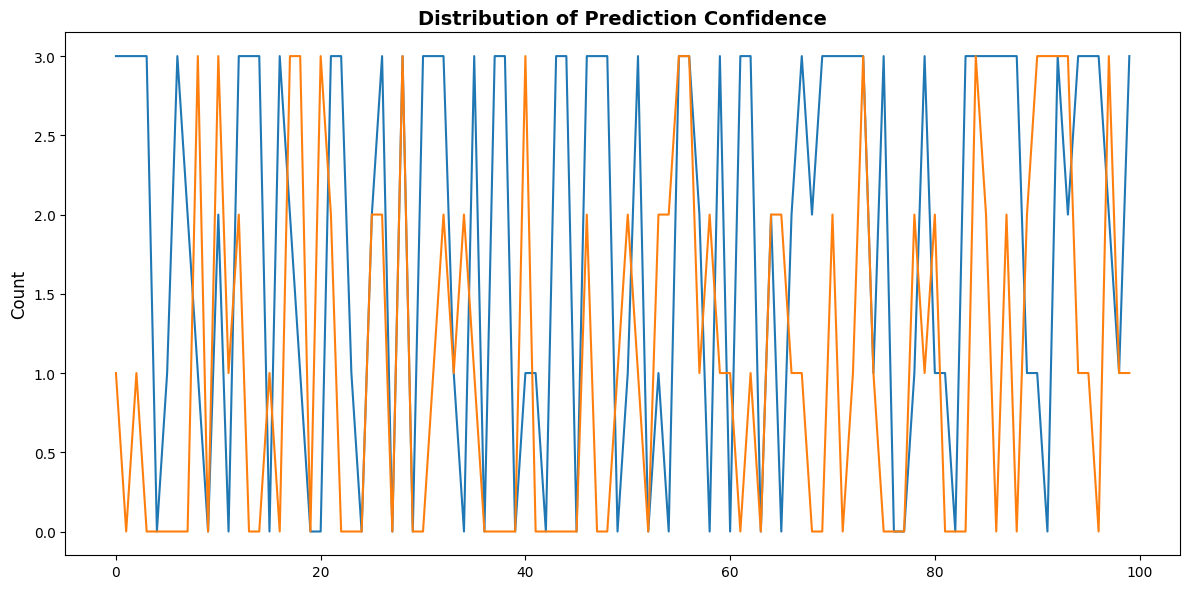

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(all_labels[100:200])
ax.plot(all_predictions[100:200])
ax.set_ylabel("Count", fontsize=12) # 
ax.set_title("Distribution of Prediction Confidence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close()

In [40]:
print(val_dataset.bp_chunks[0].std())
print(val_dataset.bp_chunks[0].mean())
print(val_dataset.bp_chunks[-1].std())
print(val_dataset.bp_chunks[-1].mean())

1.086446
0.004928038
0.77975386
0.03004276


In [78]:
images, bp, apps, tokens, labels, durations, masks = next(iter(val_loader))
print(f"Batch labels: {labels.numpy()}") 
print(f"Class counts in this batch: {np.bincount(labels.numpy(), minlength=4)}")

Batch labels: [0 3 3 3 2 3 1 0 3 3 3 1 3 3 3 3 1 1 0 0 0 3 2 0 1 3 1 3 0 2 3 3]
Class counts in this batch: [ 7  6  3 16]


In [42]:
print(f"EEG Split: {len(val_dataset.eeg_chunks_split)}")
print(f"BP Split: {len(val_dataset.bp_chunks_split)}")
print(f"Sampler Weights: {len(val_sample_weights)}")

EEG Split: 1516
BP Split: 1516
Sampler Weights: 1516
